In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 🧠 Task 2: Advanced Data Classification Using AI

## 📌 Project Overview

This project demonstrates a complete supervised machine learning pipeline using the Breast Cancer Wisconsin Dataset.

The objective is to classify tumors as **Benign** or **Malignant** using multiple machine learning algorithms and evaluate their performance using industry-standard metrics.

---

## 🎯 Objectives

* Load and understand a real-world dataset
* Perform Exploratory Data Analysis (EDA)
* Train multiple classification models
* Compare model performance
* Perform Hyperparameter Tuning
* Evaluate using advanced metrics
* Explain predictions using Feature Importance
* Save the trained model for deployment

---

## 🛠 Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-Learn
* Joblib

---

## 📊 Machine Learning Workflow

Dataset → EDA → Preprocessing → Train/Test Split → Model Training → Hyperparameter Tuning → Evaluation → Explainability → Model Saving


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import joblib

In [3]:
cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(
    cancer.target,
    name="target"
)

print("Dataset Shape:", X.shape)
print("Target Names:", cancer.target_names)

X.head()

Dataset Shape: (569, 30)
Target Names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print("Missing Values:")
print(X.isnull().sum().sum())

print("\nClass Distribution:")
print(y.value_counts())

Missing Values:
0

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


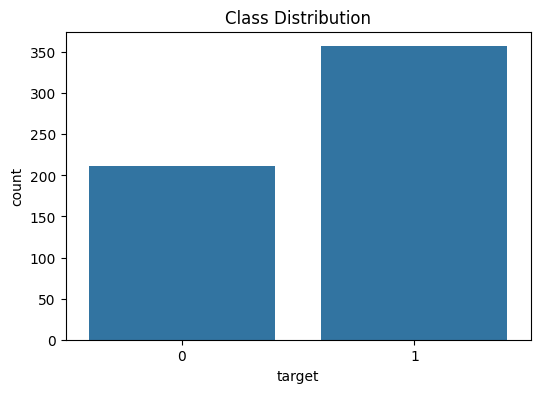

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")

plt.show()

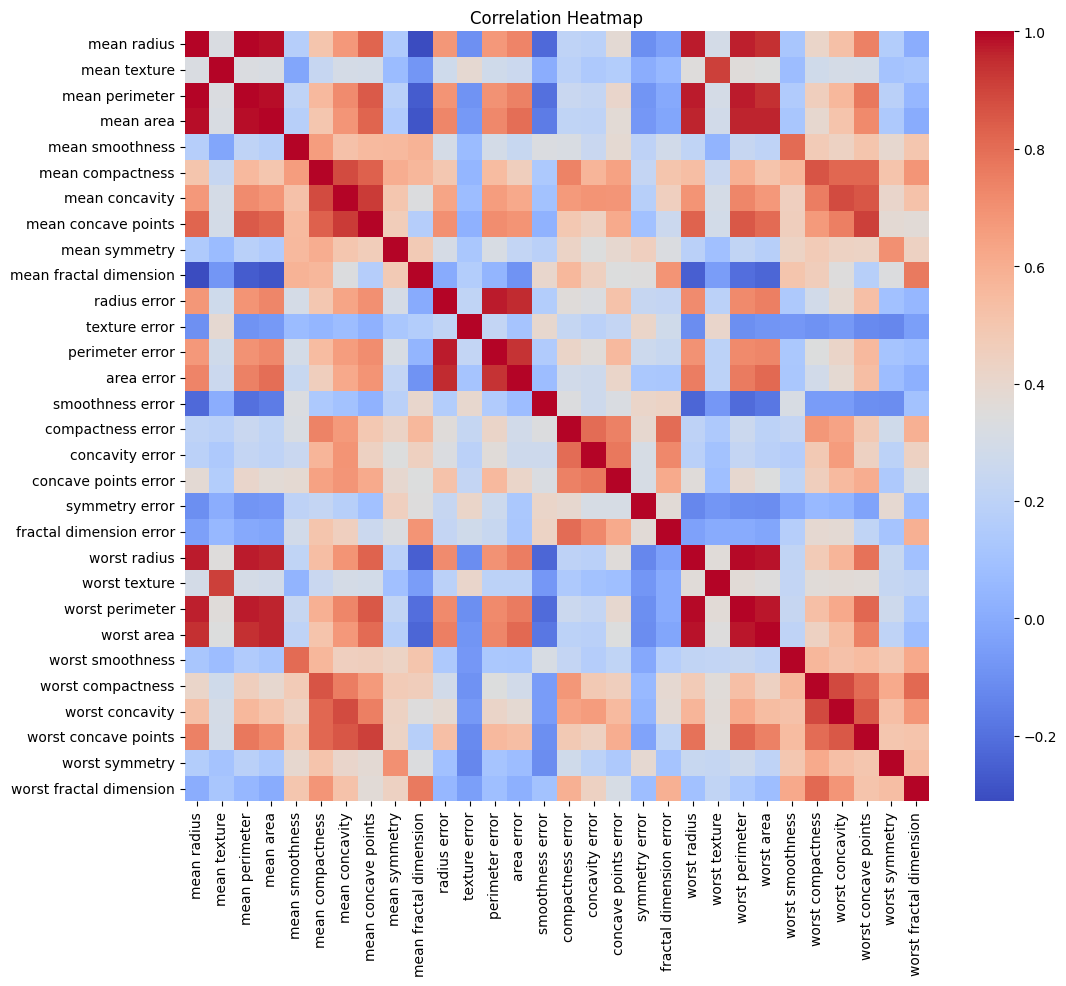

In [6]:
plt.figure(figsize=(12,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ✂️ Train-Test Split

The dataset is divided into:

* 80% Training Data
* 20% Testing Data

Training data teaches patterns to the model.

Testing data evaluates performance on unseen samples.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


In [8]:
models = {

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "SVM":
        SVC(probability=True),

    "KNN":
        KNeighborsClassifier()

}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results.append([name, accuracy])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Logistic Regression,0.964912
0,Random Forest,0.956140
3,SVM,0.929825
2,Decision Tree,0.912281
4,KNN,0.912281


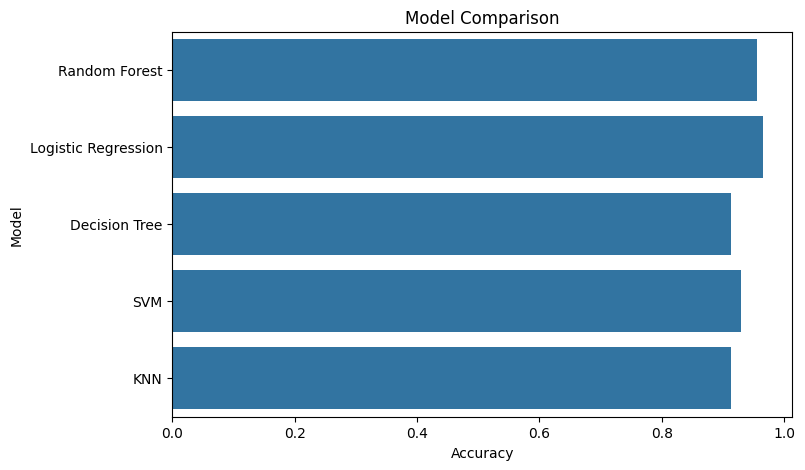

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")

plt.show()

In [10]:
rf_model = RandomForestClassifier(
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]

Average Accuracy:
0.9560937742586555


In [11]:
param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, None],

    "min_samples_split": [2, 5]

}

grid = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring="accuracy"

)

grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [12]:
predictions = best_model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Final Accuracy:")
print(round(
    accuracy * 100,
    2
), "%")

Final Accuracy:
95.61 %


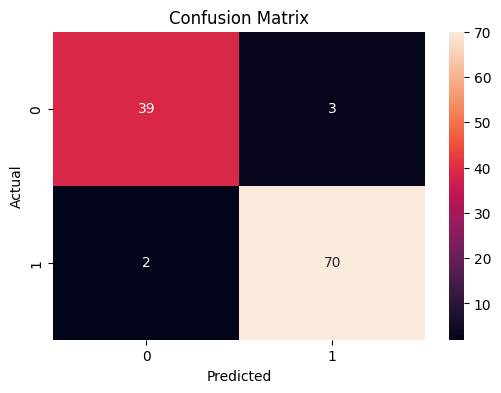

In [13]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



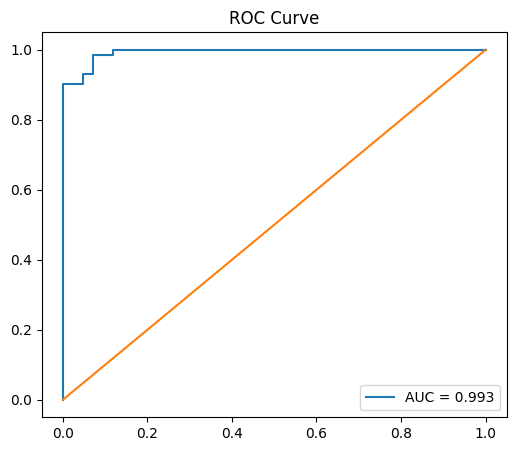

In [15]:
probabilities = best_model.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    probabilities
)

auc_score = roc_auc_score(
    y_test,
    probabilities
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1]
)

plt.legend()

plt.title("ROC Curve")

plt.show()

In [16]:
importance_df = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        best_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(
    importance_df.head(10)
)

,Feature,Importance
22,worst perimeter,0.133143
23,worst area,0.128052
27,worst concave points,0.108256
7,mean concave points,0.094300
20,worst radius,0.090606
0,mean radius,0.058662
2,mean perimeter,0.055157
3,mean area,0.049915
6,mean concavity,0.046293
26,worst concavity,0.035358


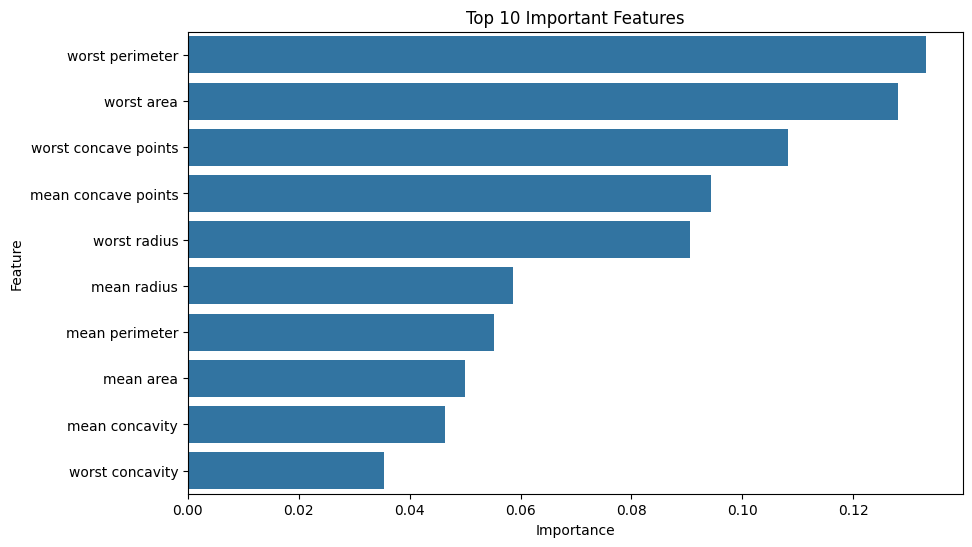

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [18]:
joblib.dump(
    best_model,
    "breast_cancer_classifier.pkl"
)

print(
    "Model Saved Successfully!"
)

Model Saved Successfully!


In [19]:
joblib.dump(best_model, "breast_cancer_classifier.pkl")

['breast_cancer_classifier.pkl']

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://efa6382d7b61dc059e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


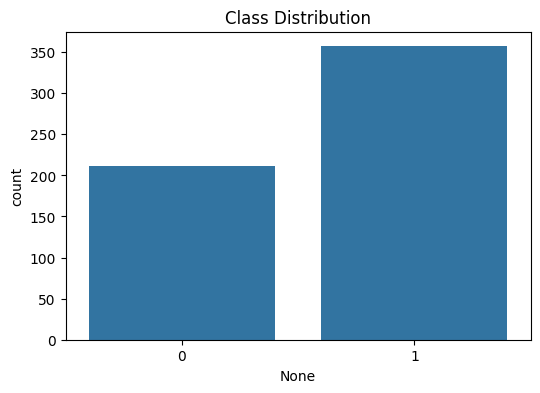

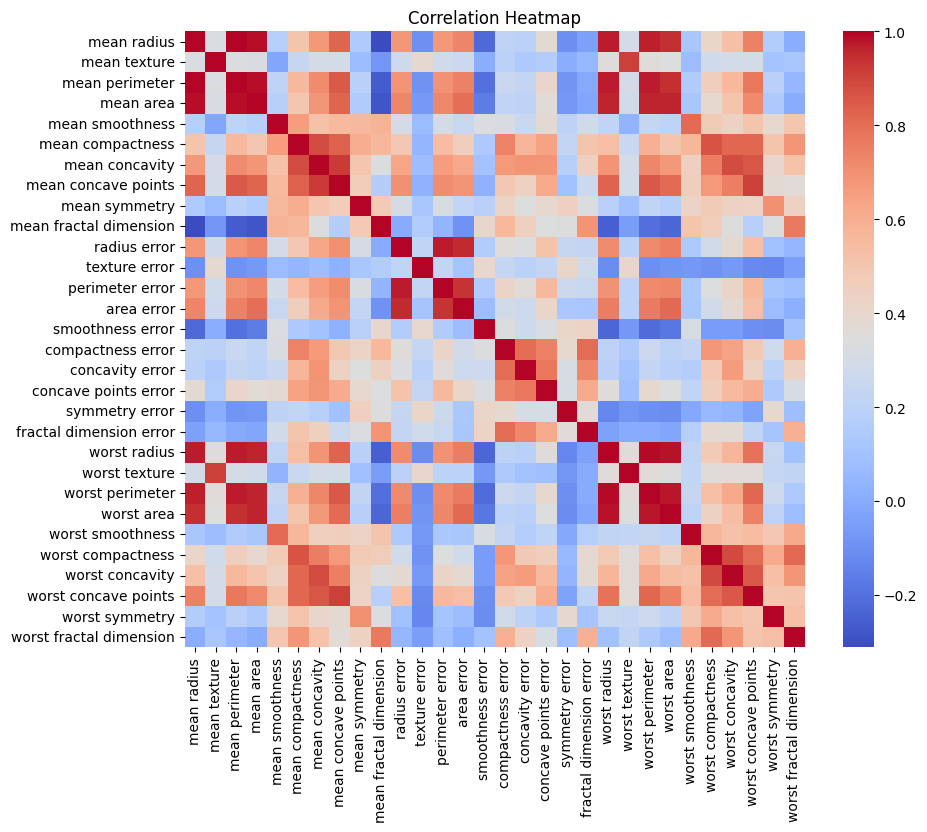

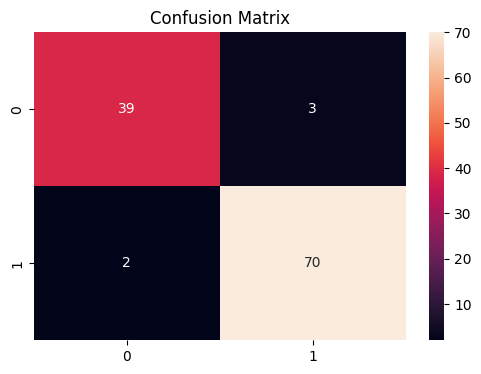

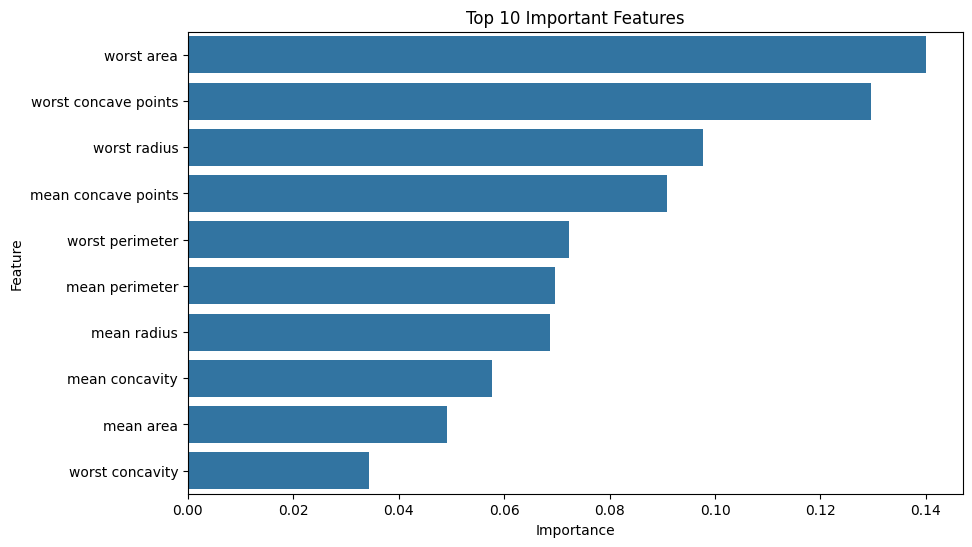

In [20]:

import gradio as gr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# ==================================
# LOAD DATA
# ==================================

cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(cancer.target)

# ==================================
# TRAIN MODEL
# ==================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# ==================================
# DATASET OVERVIEW
# ==================================

def dataset_summary():

    summary = pd.DataFrame({

        "Metric":[
            "Total Samples",
            "Total Features",
            "Benign Cases",
            "Malignant Cases"
        ],

        "Value":[
            len(X),
            X.shape[1],
            sum(y==1),
            sum(y==0)
        ]
    })

    return summary

# ==================================
# CLASS DISTRIBUTION
# ==================================

def class_distribution():

    fig, ax = plt.subplots(figsize=(6,4))

    sns.countplot(x=y, ax=ax)

    ax.set_title("Class Distribution")

    return fig

# ==================================
# CORRELATION HEATMAP
# ==================================

def correlation_heatmap():

    fig, ax = plt.subplots(
        figsize=(10,8)
    )

    sns.heatmap(
        X.corr(),
        cmap="coolwarm",
        ax=ax
    )

    ax.set_title(
        "Correlation Heatmap"
    )

    return fig

# ==================================
# CONFUSION MATRIX
# ==================================

def confusion_matrix_plot():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    fig, ax = plt.subplots(
        figsize=(6,4)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax
    )

    ax.set_title(
        "Confusion Matrix"
    )

    return fig

# ==================================
# FEATURE IMPORTANCE
# ==================================

def feature_importance():

    importance_df = pd.DataFrame({

        "Feature":
            X.columns,

        "Importance":
            model.feature_importances_

    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    fig, ax = plt.subplots(
        figsize=(10,6)
    )

    sns.barplot(

        data=importance_df.head(10),

        x="Importance",

        y="Feature",

        ax=ax

    )

    ax.set_title(
        "Top 10 Important Features"
    )

    return fig

# ==================================
# MODEL COMPARISON
# ==================================

def model_comparison():

    results = pd.DataFrame({

        "Model":[
            "Random Forest"
        ],

        "Accuracy":[
            model.score(
                X_test,
                y_test
            )
        ]

    })

    return results

# ==================================
# DASHBOARD
# ==================================

with gr.Blocks() as demo:

    gr.Markdown(
        "# 🧠 AI Cancer Classification Dashboard"
    )

    with gr.Tab("Dataset Overview"):

        gr.DataFrame(
            value=dataset_summary()
        )

    with gr.Tab("Class Distribution"):

        gr.Plot(
            value=class_distribution
        )

    with gr.Tab("Correlation Heatmap"):

        gr.Plot(
            value=correlation_heatmap
        )

    with gr.Tab("Confusion Matrix"):

        gr.Plot(
            value=confusion_matrix_plot
        )

    with gr.Tab("Feature Importance"):

        gr.Plot(
            value=feature_importance
        )

    with gr.Tab("Model Performance"):

        gr.DataFrame(
            value=model_comparison()
        )

demo.launch()

